# PhysioNet EEGNet Embedding Masking — Adaptive Random Forest Attack

This notebook tests whether the previously selected feature masks remain
effective against a stronger nonlinear privacy attacker.

**Important:** the earlier final attacker was multinomial Logistic Regression.
Random Forests were used to rank features, but not for the reported attack.
Here, a fresh Random Forest is trained at every fold and every masking level,
including 0%, so every privacy result has a matched attacker-specific baseline.

This notebook reuses the five cached EEGNet embeddings and saved masks. It does
not retrain EEGNet and does not redesign the masks.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1. Imports and configuration

A GPU is not required. Random Forest training uses the CPU.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder

SEED = 42
N_FOLDS = 5
TRAIN_RUNS = (4, 8)
TEST_RUN = 12
MASK_PERCENTAGES = list(range(0, 81, 10))
RF_TREES = 500

DRIVE_ROOT = Path("/content/drive/MyDrive/URV_Datasets")
PHYSIONET_DIR = DRIVE_ROOT / "PhysioNet_MI"
CACHE_DIR = PHYSIONET_DIR / "eegnet_embedding_masking_cache"
RESULTS_DIR = PHYSIONET_DIR / "results"

DATA_PATH = DRIVE_ROOT / "physionet_mi_lr_imagery_subjects_1_50_with_runs.npz"
SELECTION_FILE = RESULTS_DIR / "physionet_eegnet_improved_masking_selections.csv"
LOGISTIC_SUMMARY_FILE = RESULTS_DIR / "physionet_eegnet_improved_masking_summary.csv"

DETAIL_FILE = RESULTS_DIR / "physionet_eegnet_adaptive_rf_detailed.csv"
SUMMARY_FILE = RESULTS_DIR / "physionet_eegnet_adaptive_rf_summary.csv"
COMPARISON_FILE = RESULTS_DIR / "physionet_eegnet_adaptive_rf_vs_logistic.csv"
FIGURE_FILE = RESULTS_DIR / "physionet_eegnet_adaptive_rf_comparison.png"
RUN_FILE = RESULTS_DIR / "physionet_eegnet_adaptive_rf_run.json"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Attacker: adaptive Random Forest")
print("Folds:", N_FOLDS)
print("Mask levels:", MASK_PERCENTAGES)
print("GPU not required; this notebook is CPU-based.")

Attacker: adaptive Random Forest
Folds: 5
Mask levels: [0, 10, 20, 30, 40, 50, 60, 70, 80]
GPU not required; this notebook is CPU-based.


## 2. Load labels, cached embeddings, and saved masks

In [3]:
required = [DATA_PATH, SELECTION_FILE, LOGISTIC_SUMMARY_FILE]
required += [CACHE_DIR / f"fold_{fold}_eegnet_embeddings.npz" for fold in range(1, N_FOLDS + 1)]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Required outputs from the EEGNet masking notebook are missing:\n" + "\n".join(missing)
    )

data = np.load(DATA_PATH, allow_pickle=True)
y_utility = LabelEncoder().fit_transform(data["y"])
subject_ids = np.asarray(data["subject_ids"])
run_ids = np.asarray(data["run_ids"])

selections = pd.read_csv(SELECTION_FILE).sort_values(["fold", "selection_order"])

print("Trials:", len(y_utility))
print("Subjects:", len(np.unique(subject_ids)))
print("Runs:", dict(zip(*np.unique(run_ids, return_counts=True))))
print("Saved selected features:", len(selections))


def score_metrics(y_true, prediction):
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "macro_f1": f1_score(y_true, prediction, average="macro"),
        "weighted_f1": f1_score(y_true, prediction, average="weighted"),
    }


def dense_head_predict(embeddings, kernel, bias):
    logits = embeddings @ kernel + bias
    return np.argmax(logits, axis=1)


def apply_saved_mask(X, selected_features, replacement_values):
    X_masked = X.copy()
    if len(selected_features):
        X_masked[:, selected_features] = replacement_values[selected_features]
    return X_masked


def make_adaptive_rf(seed):
    return RandomForestClassifier(
        n_estimators=RF_TREES,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced_subsample",
        bootstrap=True,
        random_state=seed,
        n_jobs=-1,
    )

Trials: 2245
Subjects: 50
Runs: {np.int64(4): np.int64(750), np.int64(8): np.int64(747), np.int64(12): np.int64(748)}
Saved selected features: 1280


## 3. Retrain the adaptive attacker at every masking level

In every fold:

- The masks and replacement means come only from the 40 outer training subjects.
- The privacy attacker learns the 10 held-out identities from runs 4 and 8.
- Privacy is tested on run 12 from those same 10 identities.
- A completely fresh Random Forest is fitted after each mask is applied.
- Utility is checked with the original trained EEGNet Dense head.

In [4]:
unique_subjects = np.unique(subject_ids)
outer_cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
all_rows = []

for fold, (train_subject_pos, test_subject_pos) in enumerate(
    outer_cv.split(unique_subjects), start=1
):
    train_subjects = unique_subjects[train_subject_pos]
    test_subjects = unique_subjects[test_subject_pos]

    utility_train_idx = np.flatnonzero(
        np.isin(subject_ids, train_subjects) & np.isin(run_ids, TRAIN_RUNS)
    )
    utility_test_idx = np.flatnonzero(
        np.isin(subject_ids, test_subjects) & (run_ids == TEST_RUN)
    )
    privacy_train_idx = np.flatnonzero(
        np.isin(subject_ids, test_subjects) & np.isin(run_ids, TRAIN_RUNS)
    )
    privacy_test_idx = np.flatnonzero(
        np.isin(subject_ids, test_subjects) & (run_ids == TEST_RUN)
    )

    assert set(subject_ids[utility_train_idx]).isdisjoint(set(subject_ids[utility_test_idx]))
    assert set(subject_ids[privacy_train_idx]) == set(subject_ids[privacy_test_idx])

    cache_file = CACHE_DIR / f"fold_{fold}_eegnet_embeddings.npz"
    cached = np.load(cache_file, allow_pickle=False)
    embeddings = cached["embeddings"].astype(np.float32)
    dense_kernel = cached["dense_kernel"].astype(np.float32)
    dense_bias = cached["dense_bias"].astype(np.float32)

    replacement_values = embeddings[utility_train_idx].mean(axis=0)
    fold_order = selections.loc[selections["fold"] == fold, "embedding_index"].to_numpy(dtype=int)
    n_features = embeddings.shape[1]

    if len(fold_order) < round(n_features * max(MASK_PERCENTAGES) / 100):
        raise ValueError(f"Fold {fold} does not contain enough saved mask selections.")

    privacy_encoder = LabelEncoder().fit(subject_ids[privacy_train_idx])
    y_privacy_train = privacy_encoder.transform(subject_ids[privacy_train_idx])
    y_privacy_test = privacy_encoder.transform(subject_ids[privacy_test_idx])

    for percentage in MASK_PERCENTAGES:
        n_masked = int(round(n_features * percentage / 100.0))
        selected_features = fold_order[:n_masked]

        utility_X = apply_saved_mask(
            embeddings[utility_test_idx], selected_features, replacement_values
        )
        utility_prediction = dense_head_predict(utility_X, dense_kernel, dense_bias)
        all_rows.append({
            "fold": fold,
            "mask_percentage": percentage,
            "n_masked": n_masked,
            "task": "utility",
            "attacker": "not applicable",
            "n_classes": 2,
            "chance_accuracy": 0.5,
            **score_metrics(y_utility[utility_test_idx], utility_prediction),
        })

        privacy_X_train = apply_saved_mask(
            embeddings[privacy_train_idx], selected_features, replacement_values
        )
        privacy_X_test = apply_saved_mask(
            embeddings[privacy_test_idx], selected_features, replacement_values
        )

        attacker = make_adaptive_rf(SEED + fold * 100 + percentage)
        attacker.fit(privacy_X_train, y_privacy_train)
        privacy_prediction = attacker.predict(privacy_X_test)
        all_rows.append({
            "fold": fold,
            "mask_percentage": percentage,
            "n_masked": n_masked,
            "task": "privacy",
            "attacker": "adaptive RandomForestClassifier",
            "n_classes": len(privacy_encoder.classes_),
            "chance_accuracy": 1 / len(privacy_encoder.classes_),
            **score_metrics(y_privacy_test, privacy_prediction),
        })

        print(
            f"Fold {fold}/5, mask={percentage:>2}%: "
            f"utility BA={all_rows[-2]['balanced_accuracy']:.3f}, "
            f"RF privacy BA={all_rows[-1]['balanced_accuracy']:.3f}"
        )

Fold 1/5, mask= 0%: utility BA=0.672, RF privacy BA=0.473
Fold 1/5, mask=10%: utility BA=0.665, RF privacy BA=0.500
Fold 1/5, mask=20%: utility BA=0.665, RF privacy BA=0.473
Fold 1/5, mask=30%: utility BA=0.679, RF privacy BA=0.527
Fold 1/5, mask=40%: utility BA=0.665, RF privacy BA=0.507
Fold 1/5, mask=50%: utility BA=0.685, RF privacy BA=0.487
Fold 1/5, mask=60%: utility BA=0.705, RF privacy BA=0.460
Fold 1/5, mask=70%: utility BA=0.678, RF privacy BA=0.453
Fold 1/5, mask=80%: utility BA=0.678, RF privacy BA=0.420
Fold 2/5, mask= 0%: utility BA=0.636, RF privacy BA=0.553
Fold 2/5, mask=10%: utility BA=0.629, RF privacy BA=0.553
Fold 2/5, mask=20%: utility BA=0.636, RF privacy BA=0.553
Fold 2/5, mask=30%: utility BA=0.642, RF privacy BA=0.513
Fold 2/5, mask=40%: utility BA=0.642, RF privacy BA=0.467
Fold 2/5, mask=50%: utility BA=0.649, RF privacy BA=0.500
Fold 2/5, mask=60%: utility BA=0.649, RF privacy BA=0.407
Fold 2/5, mask=70%: utility BA=0.662, RF privacy BA=0.340
Fold 2/5, mask

## 4. Baseline-relative summary and comparison with Logistic Regression

In [5]:
results = pd.DataFrame(all_rows)

baseline = (
    results.loc[results["mask_percentage"] == 0, ["fold", "task", "balanced_accuracy"]]
    .rename(columns={"balanced_accuracy": "baseline_balanced_accuracy"})
)
results = results.merge(baseline, on=["fold", "task"], how="left")
results["utility_loss"] = np.where(
    results["task"] == "utility",
    results["baseline_balanced_accuracy"] - results["balanced_accuracy"],
    np.nan,
)
results["privacy_reduction"] = np.where(
    results["task"] == "privacy",
    results["baseline_balanced_accuracy"] - results["balanced_accuracy"],
    np.nan,
)

denominator = results["baseline_balanced_accuracy"] - results["chance_accuracy"]
results["normalized_privacy_reduction"] = np.where(
    (results["task"] == "privacy") & (denominator > 0),
    results["privacy_reduction"] / denominator,
    np.nan,
)

summary = (
    results.groupby(["mask_percentage", "n_masked", "task"], as_index=False)
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        utility_loss_mean=("utility_loss", "mean"),
        privacy_reduction_mean=("privacy_reduction", "mean"),
        normalized_privacy_reduction_mean=("normalized_privacy_reduction", "mean"),
        n_evaluations=("fold", "count"),
    )
)

rf_privacy = summary[summary["task"] == "privacy"].copy()
rf_utility = summary[summary["task"] == "utility"].copy()

logistic = pd.read_csv(LOGISTIC_SUMMARY_FILE)
logistic_privacy = logistic[logistic["task"] == "privacy"][
    ["mask_percentage", "balanced_accuracy_mean", "balanced_accuracy_std"]
].rename(columns={
    "balanced_accuracy_mean": "logistic_privacy_ba_mean",
    "balanced_accuracy_std": "logistic_privacy_ba_std",
})

comparison = rf_privacy[
    ["mask_percentage", "n_masked", "balanced_accuracy_mean", "balanced_accuracy_std",
     "privacy_reduction_mean", "normalized_privacy_reduction_mean"]
].rename(columns={
    "balanced_accuracy_mean": "adaptive_rf_privacy_ba_mean",
    "balanced_accuracy_std": "adaptive_rf_privacy_ba_std",
}).merge(logistic_privacy, on="mask_percentage", how="left")

comparison = comparison.merge(
    rf_utility[["mask_percentage", "balanced_accuracy_mean", "balanced_accuracy_std"]]
    .rename(columns={
        "balanced_accuracy_mean": "utility_ba_mean",
        "balanced_accuracy_std": "utility_ba_std",
    }),
    on="mask_percentage",
    how="left",
)

results.to_csv(DETAIL_FILE, index=False)
summary.to_csv(SUMMARY_FILE, index=False)
comparison.to_csv(COMPARISON_FILE, index=False)

display(comparison.style.format({
    "adaptive_rf_privacy_ba_mean": "{:.2%}",
    "adaptive_rf_privacy_ba_std": "{:.2%}",
    "logistic_privacy_ba_mean": "{:.2%}",
    "logistic_privacy_ba_std": "{:.2%}",
    "utility_ba_mean": "{:.2%}",
    "utility_ba_std": "{:.2%}",
    "privacy_reduction_mean": "{:.2%}",
    "normalized_privacy_reduction_mean": "{:.2%}",
}))

,mask_percentage,n_masked,adaptive_rf_privacy_ba_mean,adaptive_rf_privacy_ba_std,privacy_reduction_mean,normalized_privacy_reduction_mean,logistic_privacy_ba_mean,logistic_privacy_ba_std,utility_ba_mean,utility_ba_std
0,0,0,53.81%,7.43%,0.00%,0.00%,64.10%,6.12%,66.61%,2.78%
1,10,32,53.42%,7.67%,0.39%,0.76%,63.45%,7.93%,66.22%,2.75%
2,20,64,50.30%,4.77%,3.50%,7.25%,61.44%,5.91%,67.02%,3.38%
3,30,96,48.02%,5.67%,5.79%,12.06%,61.01%,5.77%,67.15%,3.26%
4,40,128,46.97%,6.31%,6.84%,14.93%,57.93%,6.55%,67.15%,3.26%
5,50,160,45.65%,5.80%,8.16%,17.82%,54.98%,7.59%,67.15%,2.56%
6,60,192,43.37%,5.22%,10.44%,23.10%,54.60%,5.23%,67.41%,2.82%
7,70,224,38.83%,4.48%,14.98%,32.59%,49.91%,2.83%,66.99%,1.71%
8,80,256,33.71%,5.55%,20.10%,44.21%,47.10%,2.89%,67.79%,2.11%


## 5. Plot and saved report

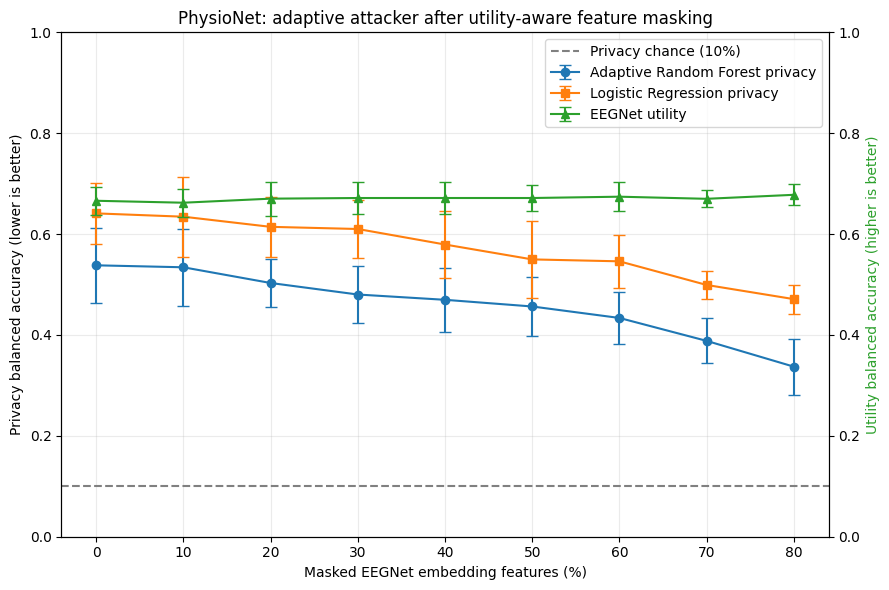

Saved detailed results: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_adaptive_rf_detailed.csv
Saved summary: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_adaptive_rf_summary.csv
Saved attacker comparison: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_adaptive_rf_vs_logistic.csv
Saved figure: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_adaptive_rf_comparison.png
Saved run metadata: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_adaptive_rf_run.json


In [6]:
fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.errorbar(
    comparison["mask_percentage"],
    comparison["adaptive_rf_privacy_ba_mean"],
    yerr=comparison["adaptive_rf_privacy_ba_std"],
    marker="o", capsize=4, label="Adaptive Random Forest privacy",
)
ax1.errorbar(
    comparison["mask_percentage"],
    comparison["logistic_privacy_ba_mean"],
    yerr=comparison["logistic_privacy_ba_std"],
    marker="s", capsize=4, label="Logistic Regression privacy",
)
ax1.axhline(0.10, color="gray", linestyle="--", label="Privacy chance (10%)")
ax1.set_xlabel("Masked EEGNet embedding features (%)")
ax1.set_ylabel("Privacy balanced accuracy (lower is better)")
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.errorbar(
    comparison["mask_percentage"],
    comparison["utility_ba_mean"],
    yerr=comparison["utility_ba_std"],
    color="tab:green", marker="^", capsize=4, label="EEGNet utility",
)
ax2.set_ylabel("Utility balanced accuracy (higher is better)", color="tab:green")
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("PhysioNet: adaptive attacker after utility-aware feature masking")
plt.tight_layout()
plt.savefig(FIGURE_FILE, dpi=180, bbox_inches="tight")
plt.show()

run_metadata = {
    "dataset": "PhysioNet EEG Motor Movement/Imagery, subjects 1-50",
    "released_representation": "masked EEGNet embedding",
    "previous_final_attacker": "multinomial Logistic Regression",
    "new_attacker": "adaptive RandomForestClassifier retrained per fold and mask level",
    "rf_trees": RF_TREES,
    "folds": N_FOLDS,
    "train_runs": list(TRAIN_RUNS),
    "test_run": TEST_RUN,
    "mask_percentages": MASK_PERCENTAGES,
    "uses_cached_eegnet_embeddings": True,
    "files": {
        "detailed": str(DETAIL_FILE),
        "summary": str(SUMMARY_FILE),
        "comparison": str(COMPARISON_FILE),
        "figure": str(FIGURE_FILE),
    },
}
with open(RUN_FILE, "w") as handle:
    json.dump(run_metadata, handle, indent=2)

print("Saved detailed results:", DETAIL_FILE)
print("Saved summary:", SUMMARY_FILE)
print("Saved attacker comparison:", COMPARISON_FILE)
print("Saved figure:", FIGURE_FILE)
print("Saved run metadata:", RUN_FILE)